## 1.Import Libraries

In [37]:
import yfinance as yf

## 2.Data Collection

In [38]:
#Download USD to LKR exchange rate data
usd_lkr=yf.download('USDLKR=X',start='2025-01-01',end='2025-12-31',interval='1wk',multi_level_index=False)

/tmp/ipykernel_917/318727829.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_lkr=yf.download('USDLKR=X',start='2025-01-01',end='2025-12-31',interval='1wk',multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


In [39]:
type(usd_lkr)

pandas.core.frame.DataFrame

In [40]:
#download Gold rate data
gold_rate=yf.download('GC=F',start='2025-01-01',end='2025-12-31',interval='1wk',multi_level_index=False)

/tmp/ipykernel_917/1329652707.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_rate=yf.download('GC=F',start='2025-01-01',end='2025-12-31',interval='1wk',multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


EXCHANGE DATA

In [41]:
usd_lkr.head()

,Close,High,Low,Open,Volume
Date,,,,,
2025-01-01,292.630676,293.501709,289.837677,289.837677,0
2025-01-08,291.400726,293.847198,289.773071,293.847198,0
2025-01-15,293.620911,294.018219,289.839020,289.839020,0
2025-01-22,295.187225,297.316833,292.439240,292.439240,0
2025-01-29,293.446228,298.604706,292.608948,293.488068,0


GOLD RATE DATA

In [42]:
gold_rate.head()

,Close,High,Low,Open,Volume
Date,,,,,
2025-01-01,2656.699951,2663.100098,2617.300049,2633.000000,3922
2025-01-08,2677.500000,2720.100098,2653.500000,2655.500000,4100
2025-01-15,2755.000000,2755.000000,2690.800049,2690.800049,6518
2025-01-22,2766.800049,2792.000000,2737.500000,2754.500000,9164
2025-01-29,2853.300049,2853.300049,2769.100098,2769.100098,174112


In [43]:
usd_lkr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52 entries, 2025-01-01 to 2025-12-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   52 non-null     float64
 1   High    52 non-null     float64
 2   Low     52 non-null     float64
 3   Open    52 non-null     float64
 4   Volume  52 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.4 KB


In [44]:
gold_rate.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52 entries, 2025-01-01 to 2025-12-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   52 non-null     float64
 1   High    52 non-null     float64
 2   Low     52 non-null     float64
 3   Open    52 non-null     float64
 4   Volume  52 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.4 KB


## 3.Data Preparation

In [45]:
usd_lkr.reset_index(inplace=True)

In [46]:
usd_lkr.head()

,Date,Close,High,Low,Open,Volume
0,2025-01-01,292.630676,293.501709,289.837677,289.837677,0
1,2025-01-08,291.400726,293.847198,289.773071,293.847198,0
2,2025-01-15,293.620911,294.018219,289.839020,289.839020,0
3,2025-01-22,295.187225,297.316833,292.439240,292.439240,0
4,2025-01-29,293.446228,298.604706,292.608948,293.488068,0


In [47]:
gold_rate.reset_index(inplace=True)

In [48]:
gold_rate.head()

,Date,Close,High,Low,Open,Volume
0,2025-01-01,2656.699951,2663.100098,2617.300049,2633.000000,3922
1,2025-01-08,2677.500000,2720.100098,2653.500000,2655.500000,4100
2,2025-01-15,2755.000000,2755.000000,2690.800049,2690.800049,6518
3,2025-01-22,2766.800049,2792.000000,2737.500000,2754.500000,9164
4,2025-01-29,2853.300049,2853.300049,2769.100098,2769.100098,174112


In [49]:
import pandas as pd
#Merge the two DataFrames on the 'date' column
df_gold=pd.merge(usd_lkr,gold_rate,on='Date',how='inner')
# Display the merged result
df_gold.head()

,Date,Close_x,High_x,Low_x,Open_x,Volume_x,Close_y,High_y,Low_y,Open_y,Volume_y
0,2025-01-01,292.630676,293.501709,289.837677,289.837677,0,2656.699951,2663.100098,2617.300049,2633.000000,3922
1,2025-01-08,291.400726,293.847198,289.773071,293.847198,0,2677.500000,2720.100098,2653.500000,2655.500000,4100
2,2025-01-15,293.620911,294.018219,289.839020,289.839020,0,2755.000000,2755.000000,2690.800049,2690.800049,6518
3,2025-01-22,295.187225,297.316833,292.439240,292.439240,0,2766.800049,2792.000000,2737.500000,2754.500000,9164
4,2025-01-29,293.446228,298.604706,292.608948,293.488068,0,2853.300049,2853.300049,2769.100098,2769.100098,174112


In [50]:
gold_usd=df_gold[['Date','Close_x','Close_y']]

In [51]:
gold_usd.head()

,Date,Close_x,Close_y
0,2025-01-01,292.630676,2656.699951
1,2025-01-08,291.400726,2677.500000
2,2025-01-15,293.620911,2755.000000
3,2025-01-22,295.187225,2766.800049
4,2025-01-29,293.446228,2853.300049


## EDA
* Handling missing values =No
* Handle inbalanced dataset =No
* Handle outliers =seen
* Encode categorical features =No
* Normalization vs Standardization=Standardize

<Axes: ylabel='Close_x'>

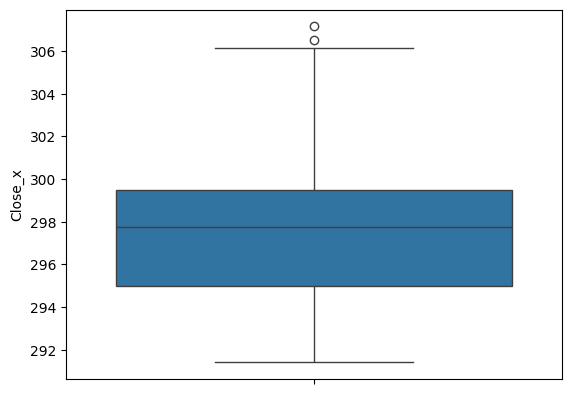

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
#for explore outliers if available
sns.boxplot(gold_usd['Close_x'])

In [53]:
gold_usd['Close_x'].max()

307.1670837402344

In [54]:
import numpy as np

q1=gold_usd['Close_x'].quantile(0.25)
q3=gold_usd['Close_x'].quantile(0.75)
iqr=q3-q1

lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)

outliers=gold_usd[(gold_usd['Close_x']>upper_bound) | (gold_usd['Close_x']<lower_bound)]
print("Outliers:")
print(outliers[['Date','Close_x']])
gold_usd['Close_x']=np.where(
    gold_usd['Close_x']>upper_bound,upper_bound,
    np.where(gold_usd['Close_x']<lower_bound,lower_bound,gold_usd['Close_x'])
)


Outliers:
         Date     Close_x
50 2025-12-17  306.544647
51 2025-12-24  307.167084


/tmp/ipykernel_917/3903271242.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_usd['Close_x']=np.where(


<Axes: xlabel='Close_x', ylabel='Close_y'>

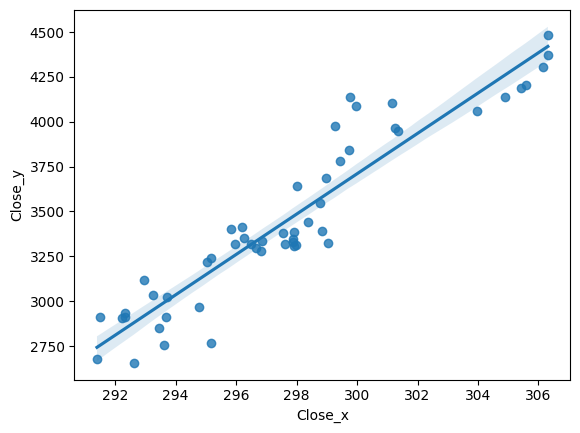

In [55]:
sns.regplot(x=gold_usd['Close_x'],y=gold_usd['Close_y'])

In [56]:
gold_usd.describe()

,Date,Close_x,Close_y
count,52,52.000000,52.000000
mean,2025-06-28 12:00:00,297.725921,3454.188462
min,2025-01-01 00:00:00,291.400726,2656.699951
25%,2025-03-31 06:00:00,294.968849,3097.949951
50%,2025-06-28 12:00:00,297.749100,3342.799927
75%,2025-09-25 18:00:00,299.505630,3867.525024
max,2025-12-24 00:00:00,306.310802,4482.799805
std,NaN,4.058869,486.266124


## 4.Model Building

In [57]:
from sklearn import set_config
set_config(display='diagram')

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x=gold_usd[['Close_x']]
y=gold_usd['Close_y']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#define Pipeline
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())

])


#fit the pipeline trainning data
pipeline.fit(x_train,y_train)



Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [59]:
#predict the test data
y_pred=pipeline.predict(x_test)

In [60]:
print(y_pred)

[3358.71511845 3705.35168483 4308.08074101 2930.20695715 3858.39151671
 3009.97358079 3288.33498274 4405.13633575 3177.52592665 3484.54861754
 3132.79612896]


In [61]:
print(y_test)

19    3280.300049
41    4087.699951
47    4186.600098
12    3118.899902
43    3947.699951
5     2912.500000
17    3411.399902
50    4482.799805
3     2766.800049
32    3313.399902
13    2968.399902
Name: Close_y, dtype: float64


In [62]:
#Actual vs Predicted
comparison_df = pd.DataFrame({
    'Actual (y_test)': y_test,
    'Predicted (y_pred)': y_pred,
    'Difference (Error)': y_test - y_pred
})

comparison_df.head(10)

,Actual (y_test),Predicted (y_pred),Difference (Error)
19,3280.300049,3358.715118,-78.415070
41,4087.699951,3705.351685,382.348266
47,4186.600098,4308.080741,-121.480643
12,3118.899902,2930.206957,188.692945
43,3947.699951,3858.391517,89.308434
5,2912.500000,3009.973581,-97.473581
17,3411.399902,3288.334983,123.064920
50,4482.799805,4405.136336,77.663469
3,2766.800049,3177.525927,-410.725878
32,3313.399902,3484.548618,-171.148715


In [63]:
pipeline.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('model', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': LinearRegression(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__copy_X': True,
 'model__fit_intercept': True,
 'model__n_jobs': None,
 'model__positive': False}

In [64]:
m=pipeline.named_steps.model.coef_[0]
b=pipeline.named_steps.model.intercept_
print(f'The linear model is y = {m:.2f}x + {b:.2f}')

The linear model is y = 432.78x + 3442.47


In [65]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mse

42397.19338239695

In [66]:
from sklearn.metrics import accuracy_score
r2=r2_score(y_test,y_pred)
r2

0.8622086348790619

## 5.Huperparameter Optimization

In [67]:
 from sklearn.model_selection import RandomizedSearchCV
 param_space={
     'model__copy_X':[True,False],
     'model__fit_intercept':[True,False],
     'model__n_jobs':[1,5,10,15,None],
     'model__positive':[True,False]

      }
random_search=RandomizedSearchCV(estimator=pipeline,param_distributions=param_space,n_iter=50,cv=5,random_state=42)

In [68]:
random_search.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model', LinearRegression())]),
                   n_iter=50,
                   param_distributions={'model__copy_X': [True, False],
                                        'model__fit_intercept': [True, False],
                                        'model__n_jobs': [1, 5, 10, 15, None],
                                        'model__positive': [True, False]},
                   random_state=42)

In [69]:
random_search.best_params_

{'model__positive': True,
 'model__n_jobs': 1,
 'model__fit_intercept': True,
 'model__copy_X': True}

In [70]:
tuned_model=LinearRegression(copy_X=True,fit_intercept=True,n_jobs=1,positive=True)

## MLOPS

In [71]:
import pickle
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

best_pipeline=random_search.best_estimator_
pickle.dump(best_pipeline,open('model.pkl','wb'))

print("Model saved successfully as model.pkl!")


Model saved successfully as model.pkl!
